_CASAのFFTと、自分のFFTを比較するために、simobserveで簡単なテストを行う_

## Simulate visibility with simobserve

In [1]:
import os, sys
import numpy as np
from astropy.constants import c
from astropy import units as u
from collections import defaultdict
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from cmcrameri import cm

from astropy.io import fits
from astropy.wcs import WCS

from casatasks import listobs, mstransform, statwt, simobserve, tclean, exportfits, uvsub, immoments
from casatools import ms, table

from glint.beam import cleanbeam_from_header
import glint.lensing as ls
from glint.context import ImageContext
from glint.forward import forward_model_3D_image
from glint.interferometer import (
    get_msdata, process_msdata,
    image_to_vis_finufft_type2, image_to_vis_finufft_type3,
)
from glint.plotstyle import set_my_plot_style

%matplotlib inline

In [2]:
set_my_plot_style()

### 適当な輝度分布を仮定

In [3]:
# 画像サイズとピクセルスケール
nx_img = ny_img = 200
pixsize_img = 0.02
x0_img, y0_img = 0.0, 0.0
xx_img, yy_img = ls.make_grid_arcsec(nx=nx_img, ny=ny_img, pixscale_arcsec=pixsize_img, x0_arcsec=x0_img, y0_arcsec=y0_img)


# test0: まず、u,vの向きを調べるために、右上に点源を置いて、得られるvisibilityをチェックする
I0 = 1.0                        # Jy/beam ではなく Jy/pixel として扱う
# sky = np.zeros((ny_img, nx_img))
# x0 = 0.
# y0 = 0
# sky[ny_img//2 + int(y0/pixsize_img), nx_img//2 + int(x0/pixsize_img)] = I0

# 真のスカイ（Jy/pixel）：正規化ガウス（半値全幅 ~0.4″）
# test1：円形ガウス
# sigma_as = 0.2               # arcsec
# sky = I0 * np.exp(-(xx_img**2 + yy_img**2)/(2*sigma_as**2))

# test2：楕円ガウス
# sigma_x, sigma_y = 0.2, 0.1
# theta = np.deg2rad(30)
# xx_rot = xx_img * np.cos(theta) + yy_img * np.sin(theta)
# yy_rot = -xx_img * np.sin(theta) + yy_img * np.cos(theta)
# sky = I0 * np.exp(-(xx_rot**2/(2*sigma_x**2) + yy_rot**2/(2*sigma_y**2)))

# test3: 視野の右上に楕円ガウス
sigma_x, sigma_y = 0.2, 0.1
theta = np.deg2rad(30)
xx_rot =  (xx_img - 0.3) * np.cos(theta) + (yy_img - 0.3) * np.sin(theta)
yy_rot = -(xx_img - 0.3) * np.sin(theta) + (yy_img - 0.3) * np.cos(theta)
sky = I0 * np.exp(-(xx_rot**2/(2*sigma_x**2) + yy_rot**2/(2*sigma_y**2)))
# sky /= np.max(sky)


# WCS（TAN、CDELT は arcsec→deg）
w = WCS(naxis=2)
h = w.to_header()
h['BUNIT'] = 'Jy/pixel'         # 重要：simobserve は Jy/pixel を想定

# proper WCS
ra0_deg  = 0
dec0_deg = 0

w = WCS(naxis=2)
# w.wcs.ctype = ['RA---TAN', 'DEC--TAN']
# w.wcs.cunit = ['deg', 'deg']
# w.wcs.cdelt = np.array([-pixsize_img/3600.0, pixsize_img/3600.0])
# w.wcs.crpix = [nx_img//2 + 1, ny_img//2 + 1]
# w.wcs.crval = [ra0_deg, dec0_deg]

h = w.to_header()
h['BUNIT'] = 'Jy/pixel'

fits.writeto('./sky_gauss.fits', sky.astype('float32'), h, overwrite=True)
print('Wrote ./sky_gauss.fits')

Wrote ./sky_gauss.fits


In [4]:
# # test4
# obsfits   = "../../data/B6_concat_cont_rob-0.5_clean.image.pbcor.cutout.fits"
# sky, obsheader = fits.getdata(obsfits, header=True)
# w = WCS(naxis=2)
# h = w.to_header()
# fits.writeto('sky_gauss.fits', sky.astype('float32'), h, overwrite=True)


# ny_img, nx_img = sky.shape
# pixsize_img = np.abs(obsheader['CDELT1'] * 3600.)
# print('Image size:', nx_img, 'x', ny_img)
# print('Image pixel scale:', pixsize_img, 'arcsec')
# x0_img, y0_img = 0.0, 0.0
# xx_img, yy_img = cl.make_grid_arcsec(nx=nx_img, ny=ny_img, pixscale_arcsec=pixsize_img, x0_arcsec=x0_img, y0_arcsec=y0_img)


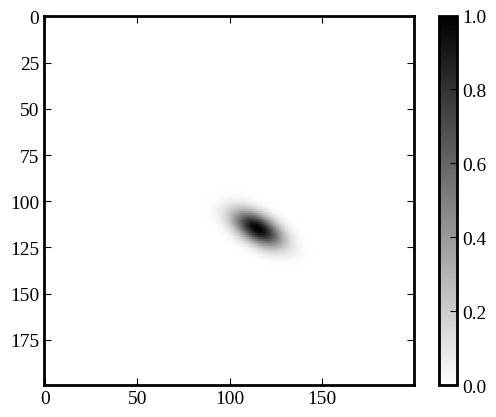

In [5]:
sky, header = fits.getdata('sky_gauss.fits', header=True)
plt.imshow(sky, cmap='gray_r', vmin=0)
plt.colorbar()
plt.show()

In [6]:
header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  200                                                  
NAXIS2  =                  200                                                  
WCSAXES =                    2 / Number of coordinate axes                      
CRPIX1  =                  0.0 / Pixel coordinate of reference point            
CRPIX2  =                  0.0 / Pixel coordinate of reference point            
CDELT1  =                  1.0 / Coordinate increment at reference point        
CDELT2  =                  1.0 / Coordinate increment at reference point        
CRVAL1  =                  0.0 / Coordinate value at reference point            
CRVAL2  =                  0.0 / Coordinate value at reference point            
LATPOLE =                 90

### simobserve

2026-08-07 12:12:00	WARN	simutil::CTPatchedInterp::interpolate	In caltable sim_imaging.alma.cycle7.5.noisy.T.cal_sim_temp (Tf Jones):
2026-08-07 12:12:00	WARN	simutil::CTPatchedInterp::interpolate+	 Insufficient solution channel sampling (nchan=1) for frequency-dependent LINEAR interpolation 
2026-08-07 12:12:00	WARN	simutil::CTPatchedInterp::interpolate+	 of calibration for MS spw=0; using NEAREST instead.


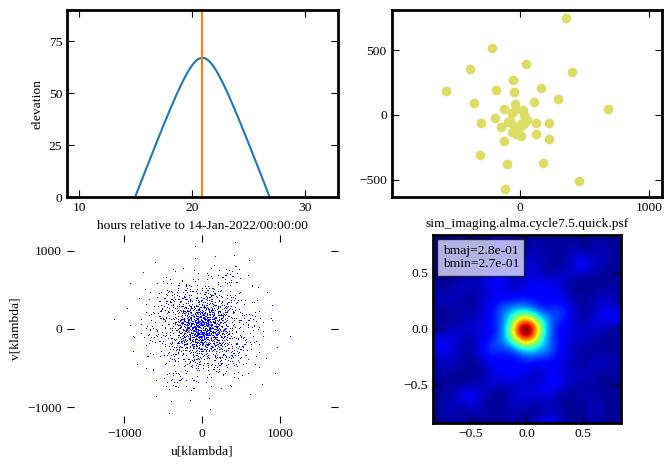

In [7]:
os.system('rm -rf sim_imaging/*')
simobserve(
    project            = 'sim_imaging',
    skymodel           = 'sky_gauss.fits', ###0埋めデータ/ノイズデータ？
    # skymodel           = '../test_diskmodeling/mock_lensed_cube.fits', ###0埋めデータ/ノイズデータ？
    # inbright           = "2Jy/pixel", ###0で装置のノイズのみになるはず？-->なってそうだけど観測時間100倍にしてもノイズ8倍くらいしか減らないのはなぜ？？
    indirection        = "J2000 00:00:00.000 +00.00.00.000", ###directionとの違いは？-->多分skymodelの一部を疑似観測する場合に使う。これはskymodelの座標を定める(ヘッダーを上書きする)。center of GOODS-ALMA。
    # indirection        = "J2000 00:00:00.000 +00.00.00.000", ###directionとの違いは？-->多分skymodelの一部を疑似観測する場合に使う。これはskymodelの座標を定める(ヘッダーを上書きする)。center of GOODS-ALMA。
    incell             = f"{pixsize_img}arcsec", ###ヘッダーを上書きするはず。
    incenter           = "270GHz", ###同じくskymodelのサブパラメータ
    inwidth            = "50MHz",
    # inwidth            = "2GHz",
    setpointings       = True, ###If true (default), calculate a map of pointings and write ptgfile. If false, read pointings from ptgfile.
    integration        = "10s", ###defaultでは10s。多分1scanの積分時間（チョッピング周期かな？）。ポインティングごとに細かく変えたい時はptgファイルで上書きできる。
    direction          = "J2000 00:00:00.000 +00.00.00.000", ###実際に観測するMosaic center
    # direction          = "J2000 00:00:00.000 +00.00.00.000", ###directionとの違いは？-->多分skymodelの一部を疑似観測する場合に使う。これはskymodelの座標を定める(ヘッダーを上書きする)。center of GOODS-ALMA。
    # mapsize            = ["-2.8arcmin", "2.8arcmin"], ###空欄(default)だとskymodelに合わせる
    maptype            = "hexagonal", ###rasterもある
    pointingspacing    = "", ###空欄でALMAのdefaultに設定される(~0.51HPBW)
    obsmode		       = "int", ###interferometer mode
    antennalist        = '../data/configuration_files/alma.cycle7.5.cfg' ,
    refdate            = "2022/1/15", ###Not critical unless concatting simulations
    hourangle          = "0h", ###「北中」する時(transitだと半分しかできない)
    totaltime          = "20s", # 72/4=18
    caldirection       = "",
    calflux            = "1Jy",
    thermalnoise       = "tsys-atm",
    user_pwv           = 0.1, ###かなり良い条件を仮定(default=0.5)
    t_ground           = 270.0, ###default=270
    seed               = 111,
    leakage            = 0.0, ###polarization leakage
    # graphics           = "none",
    verbose            = True,
    overwrite          = True
)

exportfits(imagename='./sim_imaging/sim_imaging.alma.cycle7.5.skymodel', fitsimage='./sim_imaging/skymodel.fits', dropdeg=True, overwrite=True)

In [8]:
listobs(vis='sim_imaging/sim_imaging.alma.cycle7.5.noisy.ms', listfile='sim_imaging/listobs.txt', overwrite=True)
!cat sim_imaging/listobs.txt

           MeasurementSet Name:  /lwk/atsujita/HATLASJ0900/glint/examples/test_imaging/sim_imaging/sim_imaging.alma.cycle7.5.noisy.ms      MS Version 2
   Observer: CASA simulator     Project: sim_imaging.alma.cycle7.5  
Observation: ALMA
Data records: 1806       Total elapsed time = 20 seconds
   Observed from   14-Jan-2022/20:54:52.5   to   14-Jan-2022/20:55:12.5 (UTC)

   ObservationID = 0         ArrayID = 0
  Date        Timerange (UTC)          Scan  FldId FieldName             nRows     SpwIds   Average Interval(s)    ScanIntent
  14-Jan-2022/20:54:52.5 - 20:55:12.5     1      0 sim_imaging.alma.cy*      1806  [0]  [10] [OBSERVE_TARGET#ON_SOURCE]
           (nRows = Total number of rows per scan) 
Fields: 1
  ID   Code Name                RA               Decl           Epoch   SrcId      nRows
  0    OBJ  sim_imaging.alma.cy*00:00:00.000000 +00.00.00.00000 J2000   0           1806
Spectral Windows:  (1 unique spectral windows and 1 unique polarization setups)
  SpwID  Name   #C

Max abs difference: 0.0


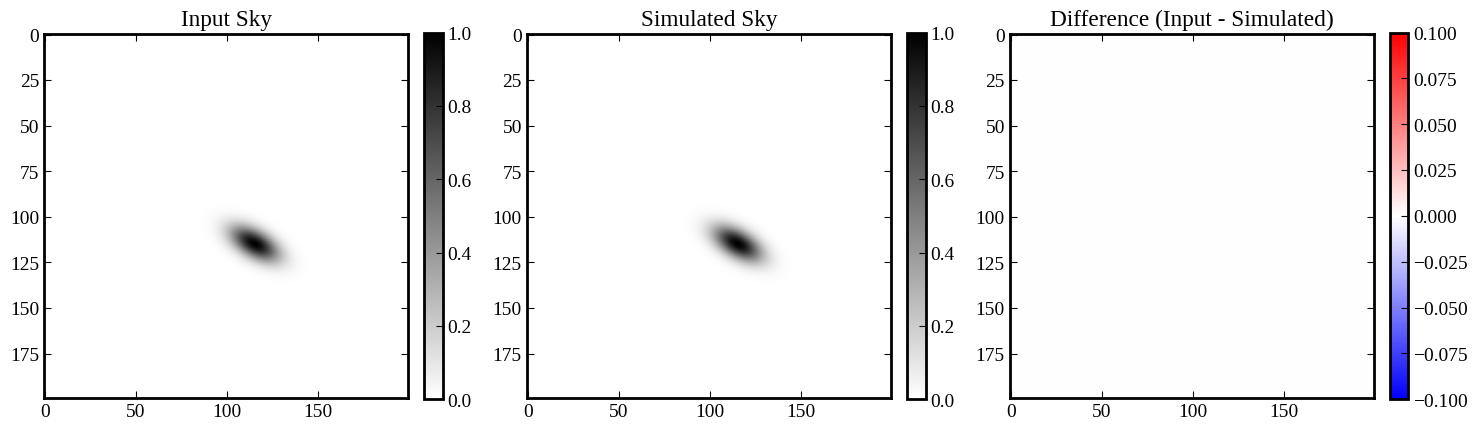

In [9]:
skymodel, skyheader = fits.getdata("./sim_imaging/skymodel.fits", header=True)
res = sky - skymodel
print('Max abs difference:', np.max(np.abs(res)))

# Comparison
f, ax = plt.subplots(1, 3, figsize=(15, 5))
im0 = ax[0].imshow(sky, cmap='gray_r', vmin=0)
ax[0].set_title('Input Sky')
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
im1 = ax[1].imshow(skymodel, cmap='gray_r', vmin=0)
ax[1].set_title('Simulated Sky')
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
im2 = ax[2].imshow(res, cmap='bwr')#, vmin=-np.max(np.abs(res)), vmax=np.max(np.abs(res)))
ax[2].set_title('Difference (Input - Simulated)')
plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [10]:
header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  200                                                  
NAXIS2  =                  200                                                  
WCSAXES =                    2 / Number of coordinate axes                      
CRPIX1  =                  0.0 / Pixel coordinate of reference point            
CRPIX2  =                  0.0 / Pixel coordinate of reference point            
CDELT1  =                  1.0 / Coordinate increment at reference point        
CDELT2  =                  1.0 / Coordinate increment at reference point        
CRVAL1  =                  0.0 / Coordinate value at reference point            
CRVAL2  =                  0.0 / Coordinate value at reference point            
LATPOLE =                 90

In [11]:
cands = {
    "orig": skymodel,
    "flipud": np.flipud(skymodel),
    "fliplr": np.fliplr(skymodel),
    "transpose": skymodel.T,
    "flipud_T": np.flipud(skymodel.T),
    "fliplr_T": np.fliplr(skymodel.T),
    "rot180": np.rot90(skymodel, 2),
}

for name, arr in cands.items():
    print(name, np.nanmax(np.abs(sky - arr)), np.sqrt(np.nanmean((sky - arr)**2)))

orig 0.0 0.0
flipud 0.9999998 0.088469386
fliplr 0.9997771 0.08666961
transpose 0.26304045 0.022362232
flipud_T 0.9999998 0.08786053
fliplr_T 0.9999998 0.08786053
rot180 0.9999903 0.08848443


### statwt

In [12]:
# statwt(vis='sim_imaging/sim_imaging.alma.cycle7.8.noisy.ms', datacolumn='data', fitspw='', combine='scan, corr', preview=False)

### 一応 CASA tclean

In [13]:
from astropy import units as u
REST_FREQ_CII = 1900.5369 * u.GHz
z = 6.024
OBS_FREQ_CII = REST_FREQ_CII / (1 + z)
print(f"Observed [CII] frequency: {OBS_FREQ_CII:.4f}")

Observed [CII] frequency: 270.5776 GHz


In [14]:
# os.system("rm -r ./sim_imaging/casa_dirty*")
# tclean(
#     vis="./sim_imaging/sim_imaging.alma.cycle7.5.noisy.ms",
#     imagename="./sim_imaging/casa_dirty",
#     imsize=nx_img,
#     cell="0.02arcsec",
#     weighting="natural",
#     niter=0,
#     stokes="I",
#     specmode="mfs",
#     # specmode="cube",
#     interactive=False,
#     # restfreq=f"{OBS_FREQ_CII.to(u.GHz).value}GHz"
# )

# exportfits(imagename='./sim_imaging/casa_dirty.image', fitsimage='./sim_imaging/casa_dirty.image.fits', overwrite=True)
# exportfits(imagename='./sim_imaging/casa_dirty.psf', fitsimage='./sim_imaging/casa_dirty.psf.fits', overwrite=True)
# exportfits(imagename='./sim_imaging/sim_imaging.alma.cycle7.5.skymodel', fitsimage='./sim_imaging/casa_dirty.skymodel.fits', overwrite=True)

In [15]:
# casa_image, casa_header = fits.getdata('./sim_imaging/casa_dirty.image.fits', header=True)
# casa_image = np.squeeze(casa_image)

# casa_beam = fits.getdata('./sim_imaging/casa_dirty.psf.fits')
# casa_beam = np.squeeze(casa_beam)

# plt.imshow(casa_image, cmap='rainbow', vmin=0)
# plt.colorbar()
# plt.show()

In [16]:
# # peak 座標
# np.unravel_index(np.argmax(casa_image), casa_image.shape), np.max(casa_image)

In [17]:
# casa_header['CDELT2'] * 3600
# crpix = casa_header['CRPIX1']
# print(f"CRPIX: {crpix} / total pixels: {nx_img}")

### NUFFT

In [18]:
# Keep CASA Measurement Set I/O separate from the NumPy processing step.
# This makes the same processing reusable for other MS datasets.


In [19]:
vis0 = "./sim_imaging/sim_imaging.alma.cycle7.5.ms"
msdata = get_msdata(vis0, data_column="DATA", spw_id=0)
uvdata = process_msdata(msdata, dish_diameter_m=12.0)
uvw = uvdata["uvw_m"]
uvw_lam = uvdata["uvw_lam"][:, 0, :]  # this test MS has one channel
data = uvdata["data"][0]
sigma = uvdata["sigma"][0]
weight = uvdata["weight"][0]
flag = uvdata["flag"][0]
freqs = uvdata["freqs_hz"]
PBfwhm = uvdata["pb_fwhm_as"]
phase_dir = uvdata["phase_center_deg"]
print(f"Number of flagged data points: {flag.sum()} / {flag.size}")

Number of flagged data points: 0 / 1806


In [20]:
print("Frequencies for SPW 0 (Hz):", freqs)
print(f"Primary beam FWHM (arcsec): {PBfwhm[0]:.3f}")
print(f"Phase center (deg): {phase_dir}")

Frequencies for SPW 0 (Hz): [2.7e+11]
Primary beam FWHM (arcsec): 21.566
Phase center (deg): [0. 0.]


In [21]:
# Polarization averaging and flag propagation are handled by process_msdata.

In [22]:
data.shape, sigma.shape, weight.shape, flag.shape, freqs.shape

((1806,), (1806,), (1806,), (1806,), (1,))

In [23]:
print("uvw (in meters) shape:", uvw.shape)
print("uvw (in wavelengths) shape:", uvw_lam.shape)

uvw (in meters) shape: (3, 1806)
uvw (in wavelengths) shape: (3, 1806)


In [24]:
# Single-channel arrays were selected in the load cell above.


In [25]:
sigma == 1/weight**0.5


array([ True,  True,  True, ...,  True,  True,  True], shape=(1806,))

In [26]:
uvw.shape

(3, 1806)

type-2: 38.802 ms
type-3: 66.580 ms
speed-up: 1.72x
max relative difference: 9.980e-08


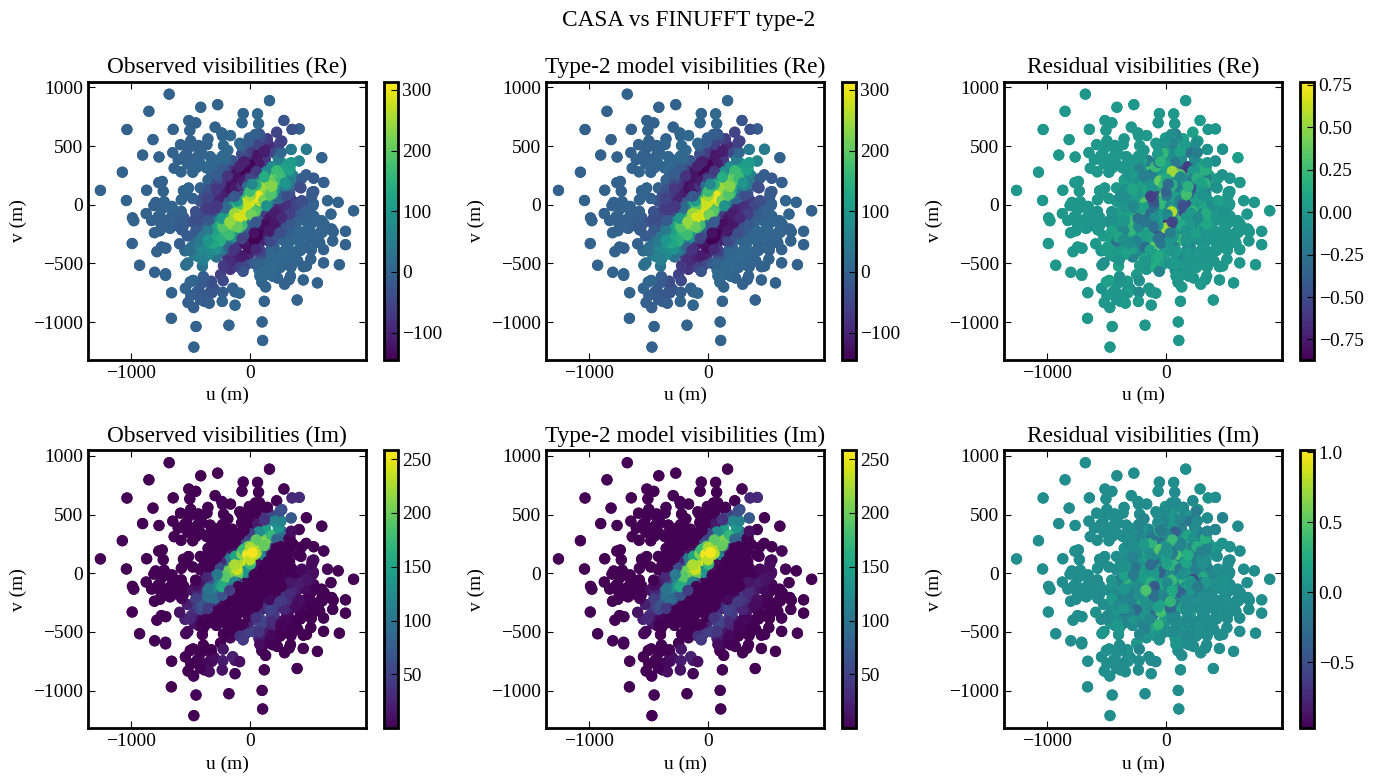

In [27]:
import time

def benchmark(func, repeat=10):
    func()  # warm up FINUFFT
    elapsed = []
    for _ in range(repeat):
        start = time.perf_counter()
        result = func()
        elapsed.append(time.perf_counter() - start)
    return result, np.median(elapsed)

model_vis_type2, time_type2 = benchmark(lambda: image_to_vis_finufft_type2(
    I=sky, ps_arcsec=pixsize_img, u=uvw_lam[0], v=uvw_lam[1], eps=1e-6
))
model_vis_type3, time_type3 = benchmark(lambda: image_to_vis_finufft_type3(
    I=sky, xx_as=xx_img, yy_as=yy_img, u=uvw_lam[0], v=uvw_lam[1], eps=1e-6
))

model_vis = model_vis_type3  # Keep the following CASA comparison unchanged.
relative_difference = (
    np.max(np.abs(model_vis_type2 - model_vis_type3))
    / np.max(np.abs(model_vis_type3))
)
print(f"type-2: {time_type2 * 1e3:.3f} ms")
print(f"type-3: {time_type3 * 1e3:.3f} ms")
print(f"speed-up: {time_type3 / time_type2:.2f}x")
print(f"max relative difference: {relative_difference:.3e}")

# CASA visibility and type-2 model
obs_Re, obs_Im = np.real(data), np.imag(data)
mod_Re, mod_Im = np.real(model_vis_type2), np.imag(model_vis_type2)
res_Re, res_Im = obs_Re - mod_Re, obs_Im - mod_Im
vmax_re, vmin_re = np.max(obs_Re), np.min(obs_Re)
vmax_im, vmin_im = np.max(np.abs(obs_Im)), np.min(np.abs(obs_Im))
u, v = uvw[0], uvw[1]

f, ax = plt.subplots(2, 3, figsize=(14, 8))
im = [
    ax[0, 0].scatter(u, v, c=obs_Re, s=50, vmin=vmin_re, vmax=vmax_re),
    ax[0, 1].scatter(u, v, c=mod_Re, s=50, vmin=vmin_re, vmax=vmax_re),
    ax[0, 2].scatter(u, v, c=res_Re, s=50),
    ax[1, 0].scatter(u, v, c=obs_Im, s=50, vmin=vmin_im, vmax=vmax_im),
    ax[1, 1].scatter(u, v, c=mod_Im, s=50, vmin=vmin_im, vmax=vmax_im),
    ax[1, 2].scatter(u, v, c=res_Im, s=50),
]
for i in range(2):
    component = 'Re' if i == 0 else 'Im'
    for j, title in enumerate(['Observed', 'Type-2 model', 'Residual']):
        ax[i, j].set_xlabel('u (m)')
        ax[i, j].set_ylabel('v (m)')
        ax[i, j].set_title(f'{title} visibilities ({component})')
        plt.colorbar(im[i * 3 + j], ax=ax[i, j])
f.suptitle('CASA vs FINUFFT type-2')
plt.tight_layout()
plt.show()

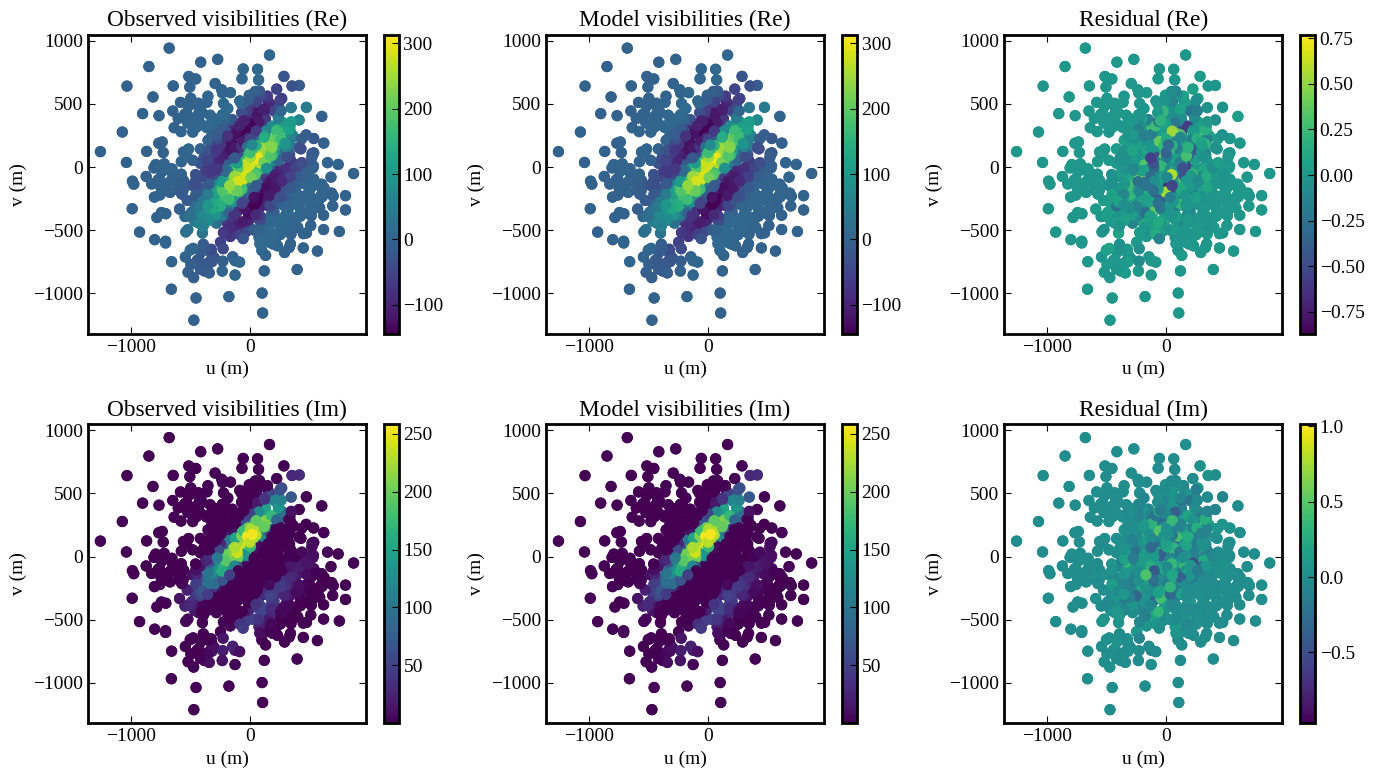

In [28]:
# simobserveの出力で得られたvisibilityとモデルのvisibilityを比較
# Re と Im 両方をプロットする
obs_Re = np.real(data)
obs_Im = np.imag(data)
mod_Re = np.real(model_vis)
mod_Im = np.imag(model_vis)
res_Re = obs_Re - mod_Re
res_Im = obs_Im - mod_Im

vmax_re = np.max(obs_Re)
vmin_re = np.min(obs_Re)
vmax_im = np.max(np.abs(obs_Im))
vmin_im = np.min(np.abs(obs_Im))

u = uvw[0]
v = uvw[1]
f, ax = plt.subplots(2, 3, figsize=(14, 8))
im0 = ax[0, 0].scatter(u, v, c=obs_Re, s=50, vmin=vmin_re, vmax=vmax_re)
im1 = ax[0, 1].scatter(u, v, c=mod_Re, s=50, vmin=vmin_re, vmax=vmax_re)
im2 = ax[0, 2].scatter(u, v, c=res_Re, s=50)
im3 = ax[1, 0].scatter(u, v, c=obs_Im, s=50, vmin=vmin_im, vmax=vmax_im)
im4 = ax[1, 1].scatter(u, v, c=mod_Im, s=50, vmin=vmin_im, vmax=vmax_im)
im5 = ax[1, 2].scatter(u, v, c=res_Im, s=50)

im = [im0, im1, im2, im3, im4, im5]
titles = ["Observed visibilities", "Model visibilities", "Residual"]

for i in range(2):
    for j in range(3):
        ax[i, j].set_xlabel("u (m)")
        ax[i, j].set_ylabel("v (m)")
        if j == 0:
            ax[i, j].set_title(f"Observed visibilities ({'Re' if i==0 else 'Im'})")
        elif j == 1:
            ax[i, j].set_title(f"Model visibilities ({'Re' if i==0 else 'Im'})")
        else:
            ax[i, j].set_title(f"Residual ({'Re' if i==0 else 'Im'})")
        plt.colorbar(im[i*3+j], ax=ax[i, j])
plt.tight_layout()
plt.show()

In [29]:
"""
まとめ
・simobserveは nx/2 を中心とするピクセル座標系を想定している。これに合わせて、make_grid_arcsecも x0_pix=nx/2.0, y0_pix=ny/2.0 とする必要がある。
"""

'\nまとめ\n・simobserveは nx/2 を中心とするピクセル座標系を想定している。これに合わせて、make_grid_arcsecも x0_pix=nx/2.0, y0_pix=ny/2.0 とする必要がある。\n'

In [30]:
stop

NameError: name 'stop' is not defined

In [ ]:
from astropy.io import fits
hdr = fits.getheader("sky_gauss.fits")
for k in ["NAXIS1","NAXIS2","CRPIX1","CRPIX2","CRVAL1","CRVAL2","CDELT1","CDELT2","CTYPE1","CTYPE2","CUNIT1","CUNIT2"]:
    print(k, hdr.get(k))

NAXIS1 201
NAXIS2 201
CRPIX1 101.0
CRPIX2 101.0
CRVAL1 0.0
CRVAL2 0.0
CDELT1 -5.5555555555556e-06
CDELT2 5.5555555555556e-06
CTYPE1 RA---TAN
CTYPE2 DEC--TAN
CUNIT1 deg
CUNIT2 deg


In [ ]:
hdr2 = fits.getheader("./sim_imaging/skymodel.fits")
for k in ["NAXIS1","NAXIS2","CRPIX1","CRPIX2","CRVAL1","CRVAL2","CDELT1","CDELT2","CTYPE1","CTYPE2","CUNIT1","CUNIT2"]:
    print(k, hdr2.get(k))

NAXIS1 201
NAXIS2 201
CRPIX1 101.5
CRPIX2 101.5
CRVAL1 0.0
CRVAL2 0.0
CDELT1 -5.555555555556e-06
CDELT2 5.555555555556e-06
CTYPE1 RA---SIN
CTYPE2 DEC--SIN
CUNIT1 deg
CUNIT2 deg


In [ ]:
import astropy.units as u
simms = 'sim_imaging/sim_imaging.alma.cycle7.5.ms'
obsid, uvw, ant1, ant2, data_pol, sigma_pol, weight_pol, data_id, time, scan, flag, phase_dir = getdata(simms)

# flagデータの割合
print(f"Flagged data fraction: {np.sum(flag) / flag.size}")
flag = flag[0]

# Get the frequencies assoc. with each spw, since uvw coordinates are in m, not wavelengths
spw = '0'
tb = table()
tb.open(simms+'/SPECTRAL_WINDOW')
t1 = tb.selectrows([int(s) for s in spw.split(',')])
freqs = np.squeeze(t1.getcol('CHAN_FREQ')) # this column is the center freq of each channel===spw
t1.close(); tb.close()

print("Frequencies for each SPW (Hz):", freqs)

# Get the primary beam size
diam = 12.0  # ALMA antenna diameter in m
PBfwhm = (1.13 * (c / np.mean(freqs*u.Hz)) / (diam*u.m) * (3600*180/np.pi)).to("")

print(f"Primary beam FWHM (arcsec): {PBfwhm:.3f}")

# Current data+sigma has two pols, average them with weighted mean
# data = np.average(data_pol, axis=0, weights=sigma_pol**-2) # テスト済み
# sigma = np.sum((sigma_pol**-2.), axis=0)**-0.5
# weight = np.sum(weight_pol, axis=0)

w_all = np.where(flag, 0.0, np.broadcast_to(weight_pol[:, None, :].astype(float), data_pol.shape))  # (2, nchan, Nrow)

num = np.sum(w_all * data_pol, axis=0)     # (nchan, Nrow)
den = np.sum(w_all, axis=0)                # (nchan, Nrow)

data  = np.divide(num, den, out=np.zeros_like(num), where=(den > 0))
weight = den.copy()
sigma  = np.full_like(den, np.inf, dtype=float)
m_ok   = den > 0
sigma[m_ok] = 1.0 / np.sqrt(den[m_ok])



# Convert uvw coords from m to wavelengths
# for i, spwid in enumerate(spw.split(',')):
#     m = (data_id == int(spwid))
#     uvw[:, m] /= c.to(u.m/u.s).value / freqs
wl_m = c.to(u.m/u.s).value / freqs  # wavelength in m (nchan, )
uvw = uvw[:, None, :] / wl_m[None, :, None]  # (3, nchan, nrow)にそれぞれbroadcast

print("Converted uvw to wavelengths.")

# phase center
tb.open(simms + "/FIELD")
phase_dir = np.squeeze(tb.getcol("PHASE_DIR"))
tb.close()
phase_dir = np.rad2deg(phase_dir)  # [rad] -> [deg]
print(f"phase center (deg): {phase_dir}")


Shape of obsid: (1806,)
Shape of uvw: (3, 1806)
Shape of ant1: (1806,)
Shape of ant2: (1806,)
Shape of data: (2, 1806)
Shape of sigma: (2, 1806)
Shape of weight: (2, 1806)
Shape of data_id: (1806,)
Shape of time: (1806,)
Shape of scan: (1806,)
Shape of flag: (2, 1806)
phase center (deg): [135.19097083   0.68977778]
Flagged data fraction: 0.0
Frequencies for each SPW (Hz): 269999999999.99997
Primary beam FWHM (arcsec): 21.566


ValueError: input operand has more dimensions than allowed by the axis remapping

In [ ]:
data[4]

array([0.50703514-0.05955252j, 0.42655718-0.00298364j,
       0.30608669+0.14004196j, ..., 0.01282501+0.04815248j,
       0.01092998-0.00342022j, 0.01392271-0.01891196j], shape=(1806,))

In [ ]:
freqs

array([2.70803214e+11, 2.70758087e+11, 2.70712959e+11, 2.70667832e+11,
       2.70622704e+11, 2.70577577e+11, 2.70532449e+11, 2.70487322e+11,
       2.70442194e+11, 2.70397067e+11, 2.70351939e+11, 2.70306812e+11])

In [ ]:
data.shape, sigma.shape, weight.shape, flag.shape, freqs.shape

((12, 1806), (12, 1806), (12, 1806), (12, 1806), (12,))

In [ ]:
sys.path.append('/home/tsujtaak/atsujita/HATLASJ0900/kinematics/delens')
import fft_uv
import importlib
importlib.reload(fft_uv)
from fft_uv import vis_to_image_finufft_type3
import calc_lensing
importlib.reload(calc_lensing)
import calc_lensing as cl

In [ ]:
from finufft import nufft2d3

i = 10

# CASA image to visibility
# skymodel = fits.getdata('./sim_imaging/casa_dirty.skymodel.fits').astype(np.float32)
skymodel = sky.astype(np.float32)

ARCSEC2RAD = np.deg2rad(1/3600)
l_rad = -(xx_img * ARCSEC2RAD).ravel().astype(np.float32, order="C")
m_rad = -(yy_img * ARCSEC2RAD).ravel().astype(np.float32, order="C")

u = uvw[0, :]
v = uvw[1, :]
kx = (2.0 * np.pi * u).astype(np.float32)
ky = (2.0 * np.pi * v).astype(np.float32)

im2vis = nufft2d3(
    x=l_rad,
    y=m_rad,
    c=skymodel[i].astype(np.complex64).ravel(),
    s=kx[i], 
    t=ky[i],
    isign=+1,
    eps=1e-6,
)

In [ ]:
freqs

array([2.70803214e+11, 2.70758087e+11, 2.70712959e+11, 2.70667832e+11,
       2.70622704e+11, 2.70577577e+11, 2.70532449e+11, 2.70487322e+11,
       2.70442194e+11, 2.70397067e+11, 2.70351939e+11, 2.70306812e+11])

In [ ]:
u, v

(array([[ -19735.36819337,    4650.22398482,   53764.44900583, ...,
         -201613.83003248,   93886.47031964,  295500.30035212],
        [ -19732.07943078,    4649.44905716,   53755.48953233, ...,
         -201580.23248242,   93870.82478885,  295451.05727127],
        [ -19728.7906682 ,    4648.67412951,   53746.53005883, ...,
         -201546.63493236,   93855.17925805,  295401.81419042],
        ...,
        [ -19705.76933011,    4643.2496359 ,   53683.81374436, ...,
         -201311.45208197,   93745.6605425 ,  295057.11262447],
        [ -19702.48056752,    4642.47470824,   53674.85427086, ...,
         -201277.85453191,   93730.01501171,  295007.86954362],
        [ -19699.19180494,    4641.69978058,   53665.89479737, ...,
         -201244.25698186,   93714.36948091,  294958.62646277]],
       shape=(12, 1806)),
 array([[   29044.14890849,   -34157.02163913,   -39581.84636114, ...,
          -467700.13733176, -1041387.05020319,  -573686.91287143],
        [   29039.30890199,   

In [ ]:
kx

array([[ -124000.98 ,    29218.219,   337812.   , ..., -1266777.   ,
          589906.06 ,  1856683.1  ],
       [ -123980.31 ,    29213.35 ,   337755.7  , ..., -1266566.   ,
          589807.8  ,  1856373.8  ],
       [ -123959.65 ,    29208.48 ,   337699.4  , ..., -1266354.9  ,
          589709.5  ,  1856064.4  ],
       ...,
       [ -123815.   ,    29174.398,   337305.34 , ..., -1264877.1  ,
          589021.4  ,  1853898.5  ],
       [ -123794.336,    29169.53 ,   337249.06 , ..., -1264666.   ,
          588923.06 ,  1853589.1  ],
       [ -123773.67 ,    29164.66 ,   337192.75 , ..., -1264455.   ,
          588824.75 ,  1853279.8  ]], shape=(12, 1806), dtype=float32)

In [ ]:
data.shape, im2vis.shape

((12, 1806), (1806,))

In [ ]:
im2vis.shape, data.shape, sigma.shape

((1806,), (12, 1806), (12, 1806))

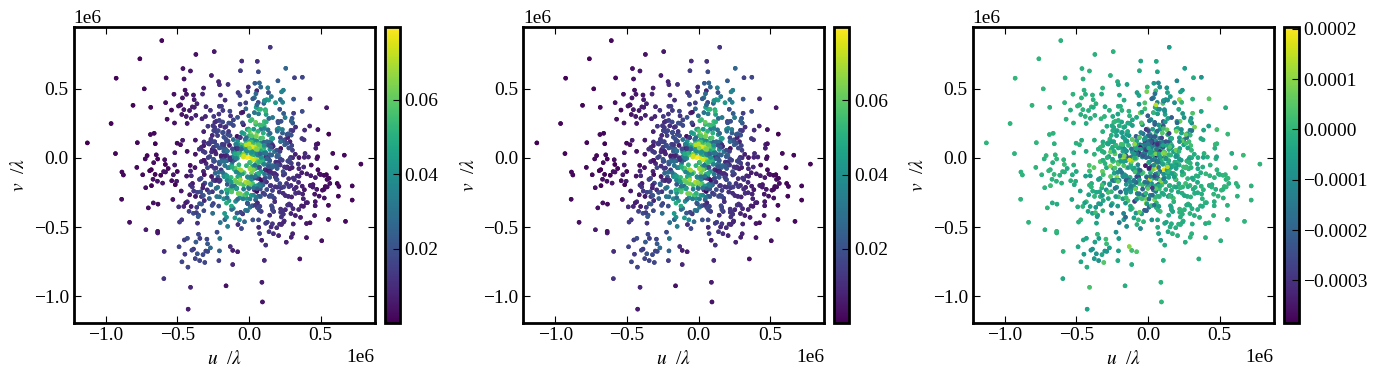

In [ ]:
# data = np.average(data_pol[:,i,:], axis=0, weights=sigma_pol**-2) # テスト済み
# sigma = np.sum((sigma_pol**-2.), axis=0)**-0.5
# weight = np.sum(weight_pol, axis=0)


obs_amp = np.abs(data[i])
mod_amp = np.abs(im2vis)
res_amp = (obs_amp - mod_amp) / 1

vmin, vmax = np.percentile(obs_amp, [5, 95])

f, ax = plt.subplots(1,3, figsize=(14,4))
im0 = ax[0].scatter(uvw[0][i], uvw[1][i], c=obs_amp, s=5)#, vmin=vmin, vmax=vmax)
im1 = ax[1].scatter(uvw[0][i], uvw[1][i], c=mod_amp, s=5)#, vmin=vmin, vmax=vmax)
im2 = ax[2].scatter(uvw[0][i], uvw[1][i], c=res_amp, s=5)#, vmin=-0.5*vmin, vmax=0.1*vmax, cmap='rainbow')

# colorbarをつける
im = [im0, im1, im2]
titles = ["Observed visibilities", "Model visibilities", "Residual (sigma units)"]
for i in range(3):
    # ax[i].set_title(titles[i])
    divider = make_axes_locatable(ax[i])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    f.colorbar(im[i], cax=cax, orientation='vertical')
    ax[i].set_xlabel(r"$u$  /$\lambda$")
    ax[i].set_ylabel(r"$v$  /$\lambda$")


plt.tight_layout()
plt.show()

In [ ]:
data[4][100]

np.complex128(-0.042710237205028534+0.06383121758699417j)

In [ ]:
im2vis[100]

np.complex64(-0.0031298322-0.0027483008j)